# Interaktive PV-Ertragsprognose (Lehrmodell Aschaffenburg)
Dieses Notebook kombiniert die physikalische PV-Modellierungsbibliothek **pvlib** mit Echtzeit-Wettervorhersagen der **Open-Meteo API**.

### Ablauf des Modells:
* **Wetterdaten:** Abruf von Temperatur, Globalstrahlung und Windgeschwindigkeit.
* **Sonnenstand:** Berechnung von Azimut und Zenitwinkel für den gewählten Standort.
* **Strahlungszerlegung:** Aufteilung der horizontalen Strahlung in Direkt- und Diffusstrahlung (*Orgill-Hollands*).
* **Ebenen-Transformation:** Umrechnung der Strahlung auf das geneigte Solardach (*Hay-Davies*).
* **PV-Wirkungsgrad & Leistung:** Berechnung der Modultemperatur (*Faiman*), des Wirkungsgrads (*ADR-Modell*) und der finalen AC/DC-Leistung (*PVWatts*).

## Schritt 1: Installation der Bibliotheken
Da Google Colab-Instanzen standardmäßig nackt starten, installieren wir zuerst die benötigten PV- und API-Pakete.

In [ ]:
!pip install --upgrade urllib3 requests
!pip install pvlib
!pip install openmeteo_requests requests_cache retry_requests

##Schritt 2: Import der notwendigen Libraries

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import pvlib
from pvlib.location import Location
from pvlib.irradiance import get_total_irradiance
from pvlib.pvarray import pvefficiency_adr

import openmeteo_requests
#requests_cache.patcher.unpatch()
import requests_cache
from retry_requests import retry

## Schritt 3: Parameter & Konfiguration (Interaktiv)
Nutze die Schieberegler auf der rechten Seite in Colab, um das System anzupassen!

Des weiteren werden im Code die Koordinaten des Systems, sowie die Modulparameter angegeben.

In [ ]:
#@title PV-Anlagenkonfiguration { run: "auto" }
TILT = 30 #@param {type:"slider", min:0, max:90, step:5}
ORIENT = 180 #@param {type:"slider", min:0, max:360, step:10}
FORECAST_DAYS = 3 #@param {type:"slider", min:1, max:7, step:1}
P_STC = 5000 #@param {type:"number"}

location_coords = (49.97, 9.15)
Aschaffenburg = Location(location_coords[0], location_coords[1], 'Europe/Berlin', 138, 'Aschaffenburg') #Standortdefinition für PV-Lib
G_STC = 1000 #Global Irradiance at Standard Test Conditions

adr_params = { #PV-Lib Modulparameter
    'k_a': 1.09707, #Skalierungsfaktor
    'k_d': -12.00000, #Dunkel-Einstrahlung
    'tc_d': 0.03927, #Temperaturkoeffizient
    'k_rs': 0.05468, #Serienwiderstand-Verlust
    'k_rsh': 0.00281 #Parallelwiderstand-Verlust
}

## Schritt 4: Wetterdaten-API abfragen
Open-Meteo

In [ ]:
def fetch_weather_forecast(days):
    cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
    retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
    openmeteo = openmeteo_requests.Client(session=retry_session)

    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": location_coords[0],
        "longitude": location_coords[1],
        "hourly": "temperature_2m,shortwave_radiation,wind_speed_10m",
        "forecast_days": days
    }

    responses = openmeteo.weather_api(url, params=params)
    response = responses[0]

    hourly = response.Hourly()
    hourly_temp = hourly.Variables(0).ValuesAsNumpy()
    hourly_ghi = hourly.Variables(1).ValuesAsNumpy()
    hourly_wind = hourly.Variables(2).ValuesAsNumpy()

    time_range = pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left"
    )

    df = pd.DataFrame({
        "mydatetime": time_range,
        "TTT": hourly_temp,
        "Rad1h": hourly_ghi,
        "FF": hourly_wind / 3.6
    })

    df['mydatetime'] = df['mydatetime'].dt.tz_localize(None)
    df.set_index('mydatetime', inplace=True)
    df = df.resample('1T').interpolate(method='time').reset_index()

    current_time = datetime.now() - timedelta(seconds=60)
    end_time = current_time + timedelta(days=days)
    df = df[(df['mydatetime'] >= current_time) & (df['mydatetime'] <= end_time)].reset_index(drop=True)
    return df

print(f"Hole aktuelle Wetterdaten für {FORECAST_DAYS} Tage von Open-Meteo...")
df_weather = fetch_weather_forecast(days=FORECAST_DAYS)

##Schritt 4.1: Wetterdaten Plotten

In [ ]:
# Erstelle ein Figure mit zwei Subplots für die Übersichtlichkeit
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# 1. Plot für die Einstrahlung (PV)
ax1.plot(df_weather['mydatetime'], df_weather['Rad1h'], color='orange', label='GHI [W/m²]')
ax1.set_title('Wetterdaten: Einstrahlung')
ax1.set_ylabel('W/m²')
ax1.grid(True, alpha=0.3)
ax1.legend()

# 2. Plot für die Temperatur
ax2.plot(df_weather['mydatetime'], df_weather['TTT'], color='red', label='Temperatur [°C]')
ax2.set_ylabel('°C')
ax2.set_title('Wetterdaten: Temperatur')
ax2.grid(True, alpha=0.3)
ax2.legend()

# 3. Plot für den Wind (neu hinzugefügt)
ax3.plot(df_weather['mydatetime'], df_weather['FF'], color='blue', label='Windgeschwindigkeit [m/s]')
ax3.set_ylabel('m/s')
ax3.set_title('Wetterdaten: Windgeschwindigkeit')
ax3.grid(True, alpha=0.3)
ax3.legend()

plt.xlabel('Zeitverlauf')
plt.tight_layout()
plt.show()

## Schritt 5: Physikalische PV-Simulation
In dieser Zelle rechnen wir die meteorologischen Messdaten in elektrische Leistung um.
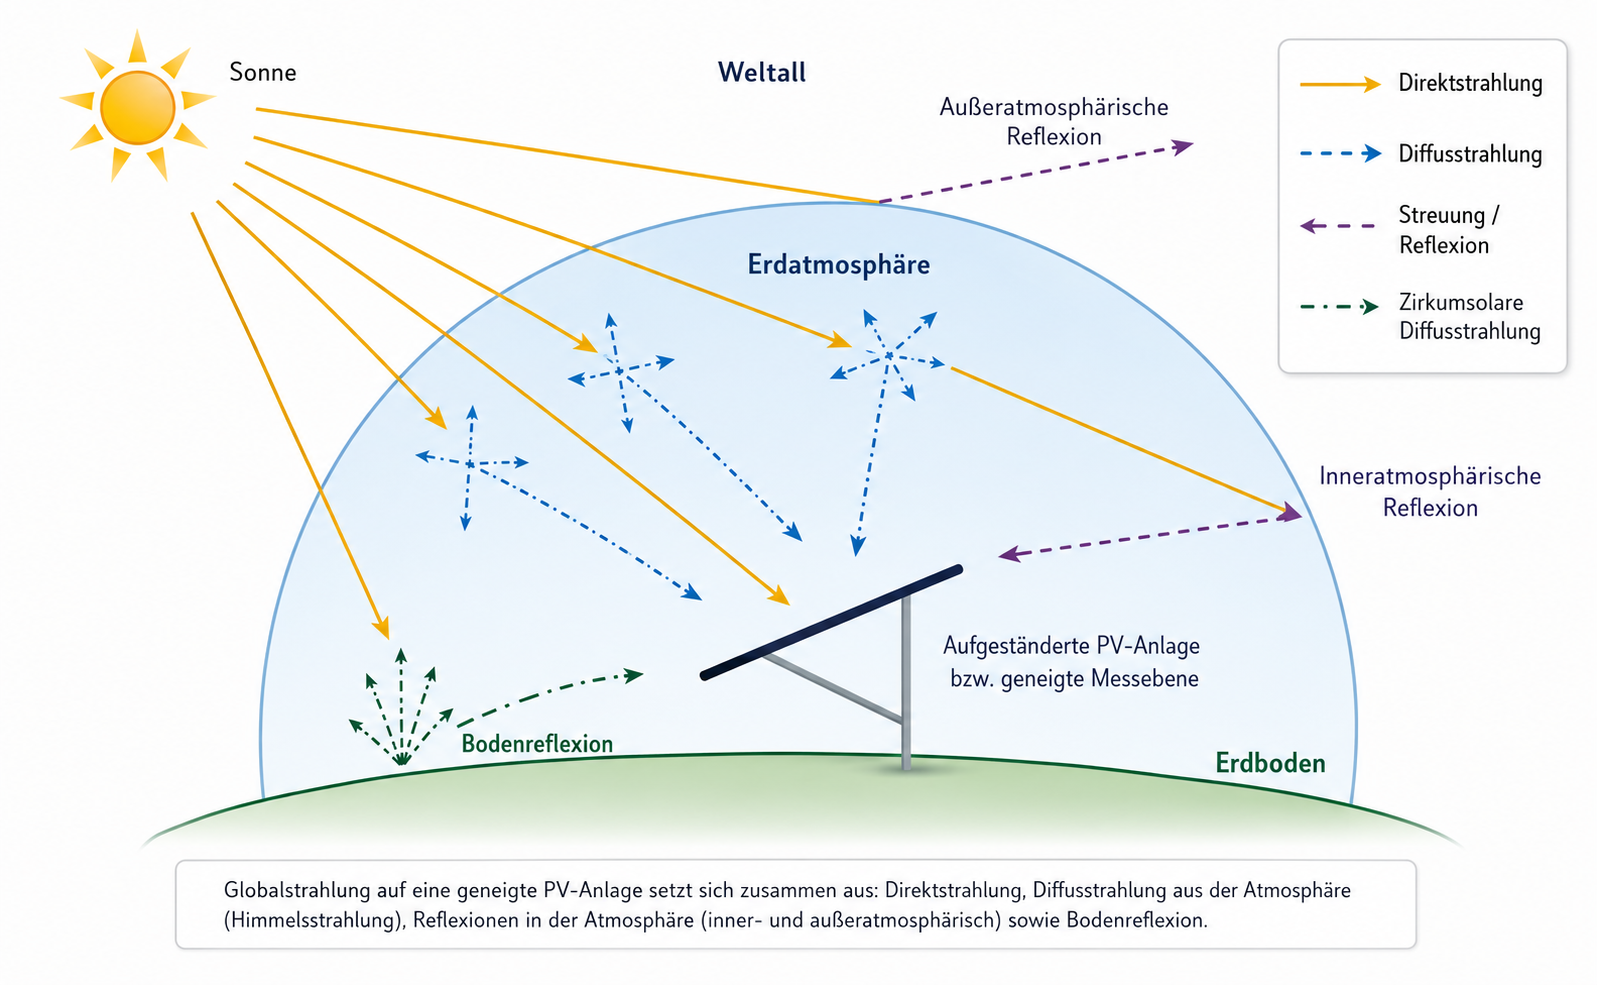

In [ ]:
print("Starte PV-Ertragssimulation...")
times = df_weather['mydatetime']
temperatures = df_weather["TTT"]
windspeed = df_weather["FF"]
ghi = df_weather["Rad1h"]
day = times.dt.dayofyear

# 1 Sonnenstand
solarposition = Aschaffenburg.get_solarposition(times, pressure=None, temperature=temperatures)
apparent_zenith = solarposition["apparent_zenith"].reset_index(drop=True)
azimuth = solarposition["azimuth"].reset_index(drop=True)

# 2 Strahlungszerlegung
irradiance_comp = pvlib.irradiance.orgill_hollands(
    ghi, apparent_zenith, day,
    dni_extra=1367, min_cos_zenith=0.065, max_zenith=87
)
dni = irradiance_comp["dni"]
dhi = irradiance_comp["dhi"]

# 3 Transformation auf die geneigte Ebene
total_irradiance = get_total_irradiance(
    TILT, ORIENT, apparent_zenith, azimuth,
    dni, ghi, dhi, dni_extra=1367, albedo=0.25, model="haydavies"
)

total_irradiance.loc[apparent_zenith > 87, 'poa_global'] = 0

# 4 Modultemperatur & Wirkungsgrad
temp_pv = pvlib.temperature.faiman(total_irradiance.poa_global, temperatures, windspeed)
eta_rel = pvefficiency_adr(total_irradiance.poa_global, temp_pv, **adr_params)

# 5 Leistungskurven
P_PV_out_DC = P_STC * eta_rel * (total_irradiance.poa_global / G_STC)
P_PV_out_DC = P_PV_out_DC.fillna(0)

P_PV_out_AC = pvlib.inverter.pvwatts(P_PV_out_DC, P_STC, eta_inv_nom=0.96, eta_inv_ref=0.9637)

##Schritt 5.1 Plot Strahlengänge

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(times, total_irradiance["poa_global"], label="Global")
plt.plot(times, total_irradiance["poa_direct"], label="Direkt")
plt.plot(times, total_irradiance["poa_sky_diffuse"], label="Himmelsdiffus")
plt.plot(times, total_irradiance["poa_ground_diffuse"], label="Bodenreflexion")

plt.ylabel("Strahlung [W/m²]")
plt.xlabel("Zeit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Schritt 5.2: Plot PV-Leistung

In [ ]:
# Erstelle das Figure-Objekt und die erste Achse (für Leistung & Einstrahlung)
fig, ax1 = plt.subplots(figsize=(14, 7))

# Erste y-Achse: Leistung und Einstrahlung
ax1.plot(times, P_PV_out_DC, label='PV Leistungsabgabe DC [W]', color='yellow', alpha=0.7)
ax1.plot(times, P_PV_out_AC, label='PV Leistungsabgabe AC [W]', color='orange', linewidth=2)
ax1.plot(times, total_irradiance.poa_global, label='Globalstrahlung Ebene [W/m²]', color='purple', alpha=0.5)

ax1.set_xlabel('Datum und Uhrzeit', fontsize=12)
ax1.set_ylabel('Leistung [W] / Einstrahlung [W/m²]', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)

# Zweite y-Achse erstellen (für Temperaturen)
ax2 = ax1.twinx()
ax2.plot(times, temp_pv, label='Modultemperatur [°C]', color='green', linestyle='--')
ax2.plot(times, temperatures, label='Umgebungstemperatur [°C]', color='red', linestyle='--')

ax2.set_ylabel('Temperatur [°C]', fontsize=12, color='black')
# Optional: Farbe der Ticks der zweiten Achse anpassen
ax2.tick_params(axis='y', labelcolor='black')

# Legende zusammenführen (über beide Achsen hinweg)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# bbox_to_anchor=(1.35, 1) verschiebt die Box weiter nach rechts
ax1.legend(lines1 + lines2, labels1 + labels2,
           title='Messgrößen',
           loc='upper left',
           bbox_to_anchor=(1.35, 1))

plt.title(f'PV Prognose Aschaffenburg ({FORECAST_DAYS}-Tage Live-Wetter)\nAusrichtung: {ORIENT}°, Neigung: {TILT}°', fontsize=14)

# WICHTIG: Damit die Legende nicht abgeschnitten wird, nutzen wir 'rect'
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.tight_layout()
plt.show()

## Schritt 6: Auswertung
Zusammenfassung der prongostizierten Erträge und Einstrahlung

In [ ]:
# ==========================================
# Energie- und Wirkungsgrad-Auswertung
# ==========================================

# Zeitschritt in Stunden bestimmen
dt_h = (times.iloc[1] - times.iloc[0]).total_seconds() / 3600

# Energieerträge
energy_dc_kwh = (P_PV_out_DC.sum() * dt_h) / 1000
energy_ac_kwh = (P_PV_out_AC.sum() * dt_h) / 1000

# Eingestrahlte Energie auf die Modulfläche
irradiation_kwh_m2 = (total_irradiance.poa_global.sum() * dt_h) / 1000

# Peak-Leistungen
max_dc_power = P_PV_out_DC.max()
max_ac_power = P_PV_out_AC.max()

print("\n" + "="*60)
print("PV-ANLAGEN AUSWERTUNG")
print("="*60)

print(f"Zeitraum:                {times.min()} bis {times.max()}")
print(f"Anlagengröße:            {P_STC/1000:.2f} kWp")

print("\nEnergieerträge")
print("-"*30)
print(f"DC-Energie:              {energy_dc_kwh:10.2f} kWh")
print(f"AC-Energie:              {energy_ac_kwh:10.2f} kWh")

print("\nLeistungen")
print("-"*30)
print(f"Max. DC-Leistung:        {max_dc_power:10.1f} W")
print(f"Max. AC-Leistung:        {max_ac_power:10.1f} W")

print("\nEinstrahlung")
print("-"*30)
print(f"POA-Einstrahlung:        {irradiation_kwh_m2:10.2f} kWh/m²")

print("="*60)